In [6]:
!python --version

Python 3.10.12


In [ ]:
! pip install kaggle


In [ ]:
! mkdir ~/.kaggle
! mkdir ~/.kaggle! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle/’: File exists
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
! kaggle datasets download -d tarundalal/dangerous-insects-dataset

Dataset URL: https://www.kaggle.com/datasets/tarundalal/dangerous-insects-dataset
License(s): CC0-1.0
 96% 430M/447M [00:03<00:00, 131MB/s] 
100% 447M/447M [00:03<00:00, 119MB/s]


In [ ]:
! unzip dangerous-insects-dataset

Archive:  dangerous-insects-dataset.zip
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_1.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_10.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_100.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_102.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_104.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_105.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_106.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_107.png  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_108.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_11.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_110.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_116.jpg  
  inflating: far

In [ ]:
! pip install split-folders

In [ ]:
import splitfolders

In [ ]:
input_file = '/content/farm_insects'
output_file = '/content/farm_insect splitted'

In [ ]:
splitfolders.ratio(input_file, output_file, seed=42, ratio=(0.8, 0.1, 0.1), group_prefix=None)

Copying files: 1591 files [00:01, 1275.14 files/s]


In [ ]:
#import libraries
import keras
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt

/bin/bash: line 1: tensorflow: command not found


In [ ]:
keras.__version__

'3.4.1'

In [ ]:
train_data_path = "/content/farm_insect splitted/train"
validation_data_path = "/content/farm_insect splitted/val"

In [ ]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

In [ ]:
training_datagen = ImageDataGenerator(rescale=1./255,
                                      rotation_range=40,
                                      width_shift_range=0.2,
                                      height_shift_range=0.2,
                                      shear_range=0.2,
                                      zoom_range=0.2,
                                      horizontal_flip=True,
                                      fill_mode='nearest')

In [ ]:
training_data = training_datagen.flow_from_directory(train_data_path, # this is the target directory
                                      target_size=(150, 150), # all images will be resized to 150x150
                                      batch_size=32,
                                      class_mode='binary')

Found 1259 images belonging to 15 classes.


In [ ]:
training_data.class_indices

{'Africanized Honey Bees (Killer Bees)': 0,
 'Aphids': 1,
 'Armyworms': 2,
 'Brown Marmorated Stink Bugs': 3,
 'Cabbage Loopers': 4,
 'Citrus Canker': 5,
 'Colorado Potato Beetles': 6,
 'Corn Borers': 7,
 'Corn Earworms': 8,
 'Fall Armyworms': 9,
 'Fruit Flies': 10,
 'Spider Mites': 11,
 'Thrips': 12,
 'Tomato Hornworms': 13,
 'Western Corn Rootworms': 14}

In [ ]:
valid_datagen = ImageDataGenerator(rescale=1./255)

# this is a similar generator, for validation data
valid_data = valid_datagen.flow_from_directory(validation_data_path,
                                  target_size=(150,150),
                                  batch_size=32,
                                  class_mode='binary')

Found 151 images belonging to 15 classes.


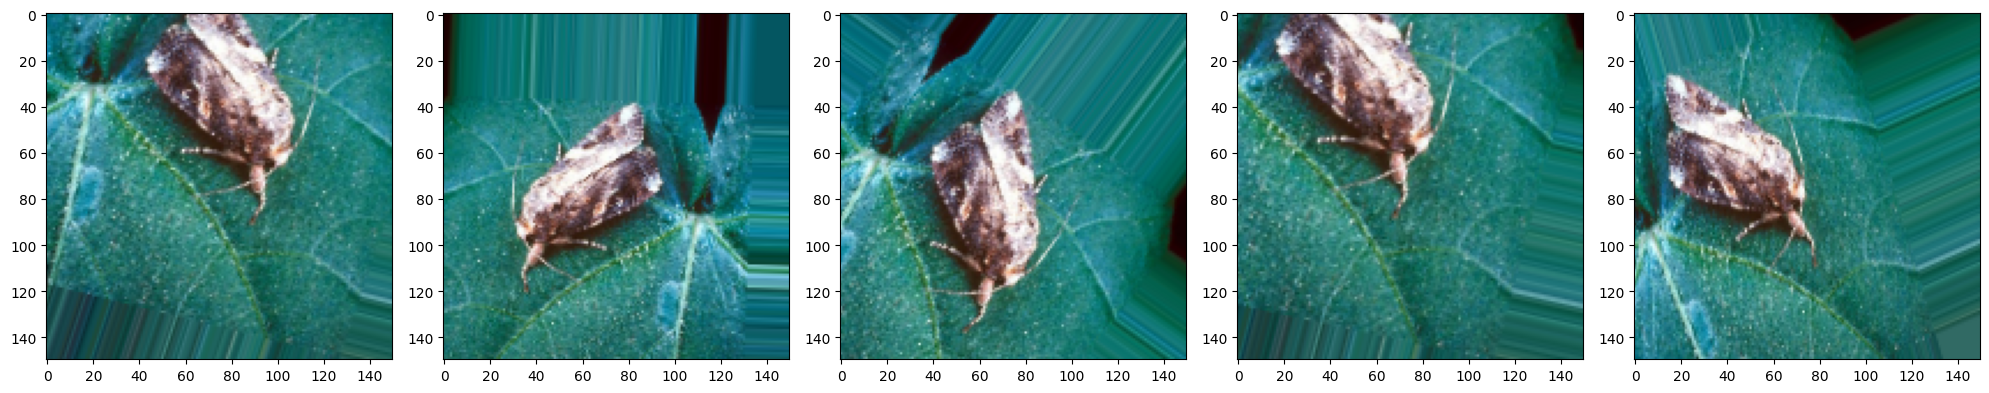

In [ ]:
images = [training_data[0][0][0] for i in range(5)]
plotImages(images)

In [ ]:
model_path = '/content/drive/MyDrive/insect_classification_model.keras'
checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]

In [ ]:
#Building cnn model
cnn_model = keras.models.Sequential([
                                    keras.layers.Conv2D(filters=32, kernel_size=3, input_shape=[150, 150, 3]),
                                    keras.layers.MaxPooling2D(pool_size=(2,2)),
                                    keras.layers.Conv2D(filters=64, kernel_size=3),
                                    keras.layers.MaxPooling2D(pool_size=(2,2)),
                                    keras.layers.Conv2D(filters=128, kernel_size=3),
                                    keras.layers.MaxPooling2D(pool_size=(2,2)),
                                    keras.layers.Conv2D(filters=256, kernel_size=3),
                                    keras.layers.MaxPooling2D(pool_size=(2,2)),

                                    keras.layers.Dropout(0.5),
                                    keras.layers.Flatten(), # neural network beulding
                                    keras.layers.Dense(units=128, activation='relu'), # input layers
                                    keras.layers.Dropout(0.1),
                                    keras.layers.Dense(units=256, activation='relu'),
                                    keras.layers.Dropout(0.25),
                                    keras.layers.Dense(units=15, activation='softmax') # output layer
])

In [ ]:
# compile cnn model
cnn_model.compile(optimizer = 'Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# train cnn model
history = cnn_model.fit(training_data,
                          epochs=100,
                          verbose=1,
                          validation_data= valid_data,
                          callbacks=callbacks_list) # time start 16.06

Epoch 1/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.0646 - loss: 2.7910
Epoch 1: val_accuracy improved from -inf to 0.14570, saving model to /content/drive/MyDrive/insect_classification_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 640ms/step - accuracy: 0.0648 - loss: 2.7902 - val_accuracy: 0.1457 - val_loss: 2.6356
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.1114 - loss: 2.6564
Epoch 2: val_accuracy did not improve from 0.14570
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 529ms/step - accuracy: 0.1112 - loss: 2.6565 - val_accuracy: 0.1192 - val_loss: 2.6143
Epoch 3/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.0963 - loss: 2.6491
Epoch 3: val_accuracy improved from 0.14570 to 0.17219, saving model to /content/drive/MyDrive/insect_classification_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 485ms/step - accuracy: 0.0972 - loss: 2.6483 - val_accuracy: 0.1722 - val_loss: 2.5664
Epoch 4/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.1314 - loss:

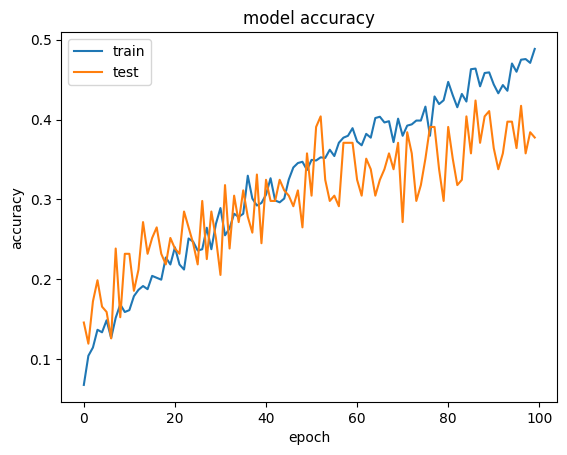

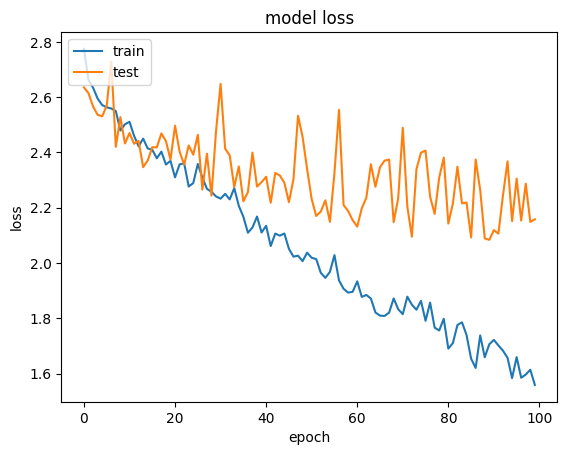

{'accuracy': [0.06751389801502228,
  0.10405083745718002,
  0.1143764927983284,
  0.13661636412143707,
  0.13343924283981323,
  0.14853057265281677,
  0.1262907087802887,
  0.1517077088356018,
  0.16838760673999786,
  0.15885622799396515,
  0.16123907268047333,
  0.17871326208114624,
  0.18665607273578644,
  0.1914217621088028,
  0.1874503642320633,
  0.20413026213645935,
  0.20174741744995117,
  0.199364572763443,
  0.22716441750526428,
  0.21842733025550842,
  0.23987291753292084,
  0.21842733025550842,
  0.21207307279109955,
  0.25099286437034607,
  0.24702145159244537,
  0.23590150475502014,
  0.23749007284641266,
  0.2644956409931183,
  0.23749007284641266,
  0.26926133036613464,
  0.28911834955215454,
  0.25496426224708557,
  0.26370134949684143,
  0.28196981549263,
  0.2779984176158905,
  0.28196981549263,
  0.3296266794204712,
  0.30103257298469543,
  0.2922954857349396,
  0.2954725921154022,
  0.3057982623577118,
  0.32644957304000854,
  0.29864972829818726,
  0.29626688361167

In [ ]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

history.history

In [ ]:
cnn_model.save('/content/drive/MyDrive/insect_classifier.h5')